In [2]:
!git config --global user.name "Ishant Jaunjal"
!git config --global user.email "ishantjaunjal2@gmail.com"

Loaded cleaned dataset : (10093, 17)
Columns                : ['area', 'property_type', 'area_sqft', 'bathrooms', 'furnishing', 'parking', 'rate_sqft', 'dist_school', 'dist_market', 'dist_hospital', 'dist_busstop', 'dist_railway', 'location_score', 'price', 'bedrooms', 'floor_num', 'building_age_yr']

Train size : 8074  |  Test size : 2019
Training Linear Regression...
Training Random Forest...

Model                          RMSE          MAE       R²
Linear Regression      ₹   866,632 ₹   380,636   0.9494
Random Forest          ₹   591,102 ₹   237,734   0.9765

Model                        MAPE     Accuracy  Within ±10%
Linear Regression           7.44%       92.56%       73.85%
Random Forest               4.43%       95.57%       92.32%
Note: Accuracy = 100 - MAPE  |  Within ±10% = % of predictions within 10% of actual


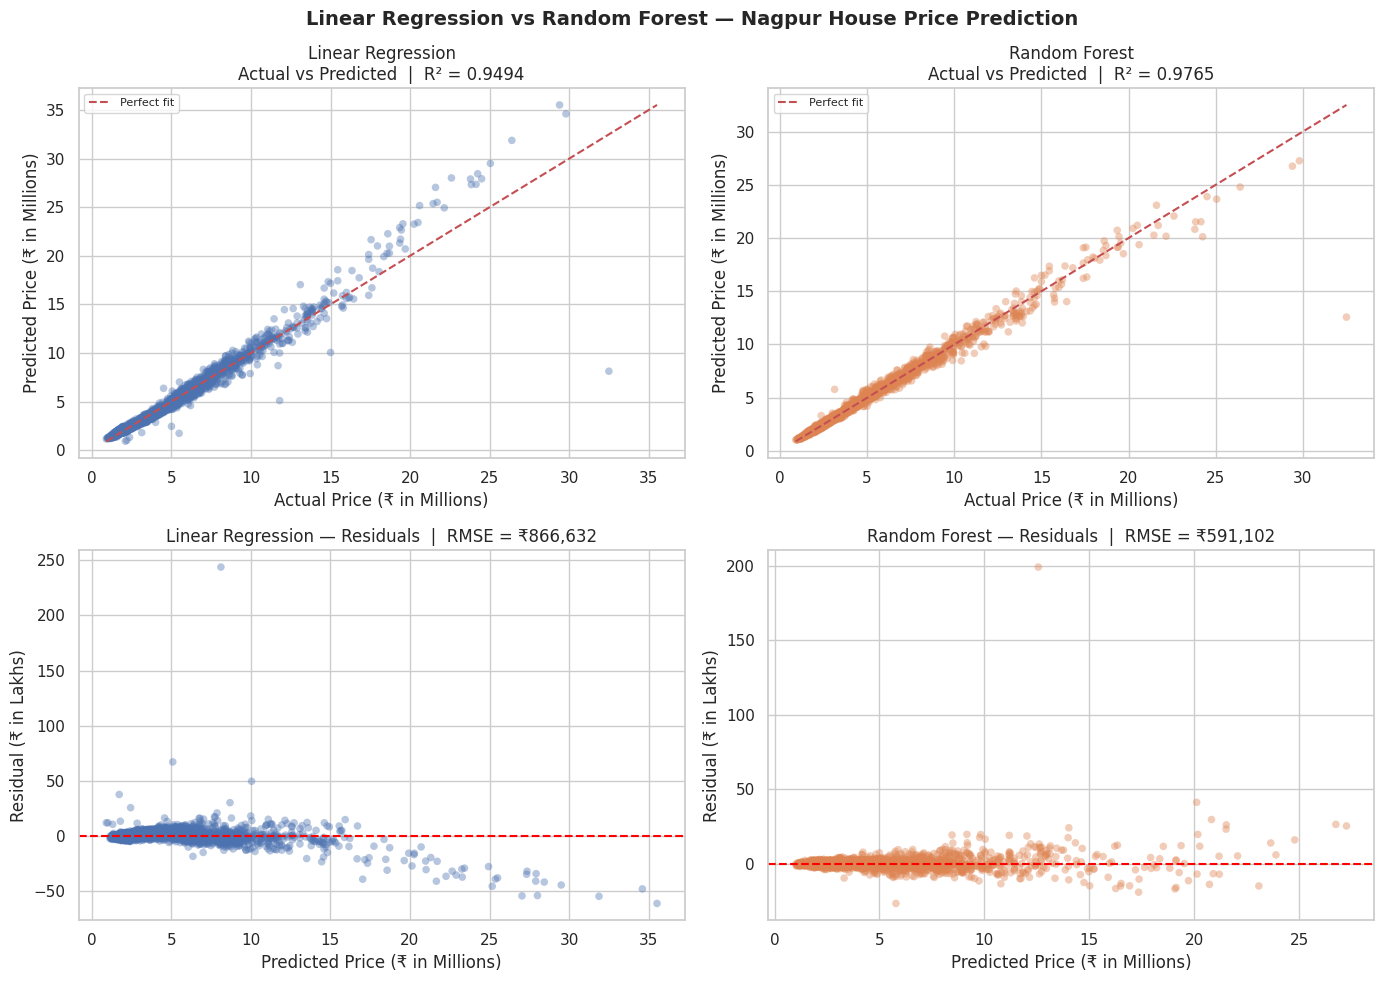


✅ Plot saved → comparison.png


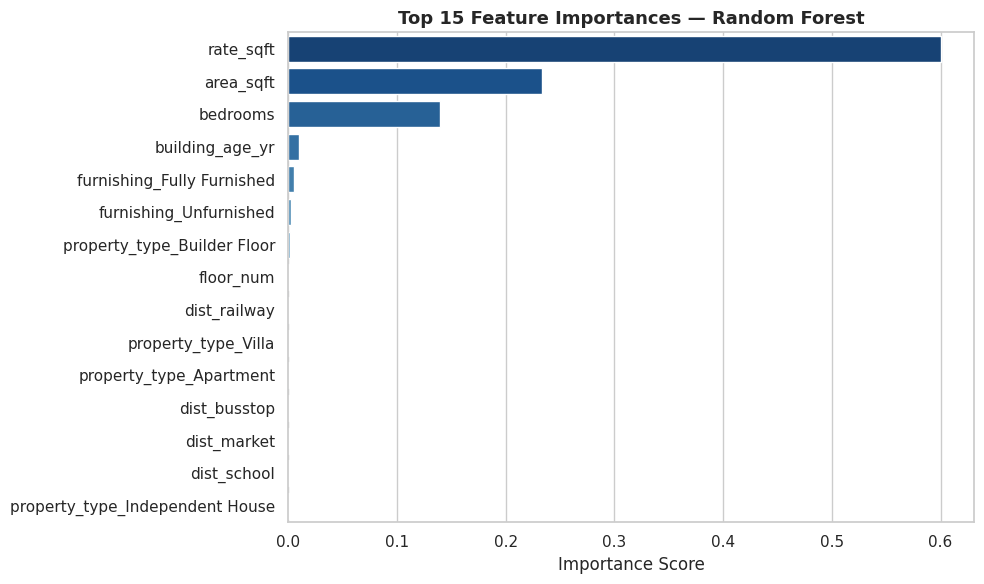

✅ Feature importance plot saved → feature_importance.png

SAMPLE PREDICTIONS (first 5 test rows)
 Actual (₹)  Linear Regression (₹)  Random Forest (₹)  LR Error (₹)  RF Error (₹)
    2349999                2103798            2233625       -246201       -116374
    9999999               10259826            9861646        259826       -138353
    3299999                3377485            3365921         77485         65921
    8400000                8283797            8155897       -116202       -244102
   11199999               11782020           10776066        582020       -423933


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
warnings.filterwarnings("ignore")

# ── 1. LOAD CLEANED DATA ──────────────────────────────────
df = pd.read_csv("/content/nagpur_cleaned.csv")

print(f"Loaded cleaned dataset : {df.shape}")
print(f"Columns                : {df.columns.tolist()}\n")

# ── 2. FEATURES & TARGET ──────────────────────────────────
numeric_features = [
    "area_sqft", "bedrooms", "bathrooms", "floor_num",
    "building_age_yr", "parking", "rate_sqft", "location_score",
    "dist_school", "dist_market", "dist_hospital",
    "dist_busstop", "dist_railway",
]
categorical_features = ["area", "property_type", "furnishing"]

X = df[numeric_features + categorical_features]
y = np.log1p(df["price"])   # log-transform to reduce skew

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size : {len(X_train)}  |  Test size : {len(X_test)}")

# ── 3. PREPROCESSING PIPELINE ─────────────────────────────
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe,     numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

# ── 4. TRAIN MODELS ───────────────────────────────────────
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...")
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds   = np.expm1(pipe.predict(X_test))
    actuals = np.expm1(y_test)
    results[name] = {
        "pipe":    pipe,
        "preds":   preds,
        "actuals": actuals,
        "rmse":    np.sqrt(mean_squared_error(actuals, preds)),
        "mae":     mean_absolute_error(actuals, preds),
        "r2":      r2_score(actuals, preds),
    }

# ── 5. METRICS ────────────────────────────────────────────
print("\n" + "=" * 56)
print(f"{'Model':<22} {'RMSE':>12} {'MAE':>12} {'R²':>8}")
print("=" * 56)
for name, r in results.items():
    print(f"{name:<22} ₹{r['rmse']:>10,.0f} ₹{r['mae']:>10,.0f} {r['r2']:>8.4f}")
print("=" * 56)

print("\n" + "=" * 56)
print(f"{'Model':<22} {'MAPE':>10} {'Accuracy':>12} {'Within ±10%':>12}")
print("=" * 56)
for name, r in results.items():
    mape     = mean_absolute_percentage_error(r["actuals"], r["preds"]) * 100
    accuracy = 100 - mape
    within   = np.mean(np.abs(r["preds"] - r["actuals"]) / r["actuals"] <= 0.10) * 100
    print(f"{name:<22} {mape:>9.2f}% {accuracy:>11.2f}% {within:>11.2f}%")
print("=" * 56)
print("Note: Accuracy = 100 - MAPE  |  Within ±10% = % of predictions within 10% of actual")

# ── 6. PLOTS — Actual vs Predicted & Residuals ────────────
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Linear Regression vs Random Forest — Nagpur House Price Prediction",
             fontsize=14, fontweight="bold")

for i, (name, r) in enumerate(results.items()):
    color = "#4C72B0" if i == 0 else "#DD8452"

    # Actual vs Predicted
    axes[0, i].scatter(r["actuals"] / 1e6, r["preds"] / 1e6,
                       alpha=0.4, s=30, color=color, edgecolors="none")
    lim = [min(r["actuals"].min(), r["preds"].min()) / 1e6,
           max(r["actuals"].max(), r["preds"].max()) / 1e6]
    axes[0, i].plot(lim, lim, "r--", linewidth=1.5, label="Perfect fit")
    axes[0, i].set_title(f"{name}\nActual vs Predicted  |  R² = {r['r2']:.4f}")
    axes[0, i].set_xlabel("Actual Price (₹ in Millions)")
    axes[0, i].set_ylabel("Predicted Price (₹ in Millions)")
    axes[0, i].legend(fontsize=8)

    # Residuals
    residuals = r["actuals"].values - r["preds"]
    axes[1, i].scatter(r["preds"] / 1e6, residuals / 1e5,
                       alpha=0.4, s=30, color=color, edgecolors="none")
    axes[1, i].axhline(0, color="red", linestyle="--", linewidth=1.5)
    axes[1, i].set_title(f"{name} — Residuals  |  RMSE = ₹{r['rmse']:,.0f}")
    axes[1, i].set_xlabel("Predicted Price (₹ in Millions)")
    axes[1, i].set_ylabel("Residual (₹ in Lakhs)")

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Plot saved → comparison.png")

# ── 7. FEATURE IMPORTANCE (Random Forest) ─────────────────
rf_pipe  = results["Random Forest"]["pipe"]
rf_model = rf_pipe.named_steps["model"]

ohe_features = (rf_pipe.named_steps["pre"]
                .named_transformers_["cat"]
                .named_steps["onehot"]
                .get_feature_names_out(categorical_features))
all_features = numeric_features + list(ohe_features)

feat_df = (pd.DataFrame({"Feature": all_features,
                          "Importance": rf_model.feature_importances_})
           .sort_values("Importance", ascending=False)
           .head(15))

fig2, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_df, x="Importance", y="Feature", palette="Blues_r", ax=ax)
ax.set_title("Top 15 Feature Importances — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature importance plot saved → feature_importance.png")

# ── 8. SAMPLE PREDICTIONS ─────────────────────────────────
print("\nSAMPLE PREDICTIONS (first 5 test rows)")
print("=" * 72)
actuals  = results["Linear Regression"]["actuals"].values[:5]
lr_preds = results["Linear Regression"]["preds"][:5]
rf_preds = results["Random Forest"]["preds"][:5]

comp = pd.DataFrame({
    "Actual (₹)":            actuals.astype(int),
    "Linear Regression (₹)": lr_preds.astype(int),
    "Random Forest (₹)":     rf_preds.astype(int),
    "LR Error (₹)":          (lr_preds - actuals).astype(int),
    "RF Error (₹)":          (rf_preds - actuals).astype(int),
})
print(comp.to_string(index=False))